# UrbanFloodBench — Training Notebook (Full Dataset)

**Approach:** Train Model 1 and Model 2 separately. One event loaded at a time from disk.  
**OOM prevention:** Events streamed from disk, gradient accumulation, no full-dataset tensors in RAM.  
**Output:** `best_model_1.pt`, `best_model_2.pt`, `submission.csv`

## Cell 1 — Install

In [3]:
import subprocess, sys, torch

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *args])

print(f'PyTorch: {torch.__version__}')
pip('torch_geometric')

tv = torch.__version__.split('+')[0]
tv_major, tv_minor = int(tv.split('.')[0]), int(tv.split('.')[1])
cuda_tag = 'cu118' if (tv_major == 2 and tv_minor <= 3) else 'cu121'
pyg_url  = f'https://data.pyg.org/whl/torch-{tv}+{cuda_tag}.html'
pip('pyarrow', 'tqdm')
print('Done.')

PyTorch: 2.9.0+cu126
Done.


## Cell 2 — Imports & config

In [4]:
import os, gc, json, random, time, warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch_geometric.nn import HeteroConv, SAGEConv
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Device ─────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# ── Paths ──────────────────────────────────────────────────────────────────
PREP_ROOT = Path('/kaggle/input/datasets/asadjabbar/urbanfloodbench-preprocessed-v1/preprocessed')
OUT_DIR   = Path('/kaggle/working')
OUT_DIR.mkdir(exist_ok=True)

# ── Hyperparameters ────────────────────────────────────────────────────────
CFG = {
    'hidden_dim':       64,
    'gru_dim':          64,
    'n_gnn_layers':     2,
    'n_mlp_layers':     2,
    'dropout':          0.1,
    'epochs':           30,
    'lr':               3e-4,
    'grad_clip':        1.0,
    'warmup_steps':     10,
    # Gradient accumulation: update weights every N events
    # Simulates a larger batch without loading multiple events into VRAM
    'accum_steps':      4,
    # Scheduled sampling: teacher forcing decays to 0 by this epoch
    'ss_decay_epochs':  20,
    # Multi-step loss horizons (introduced gradually)
    'multistep_ks':     [1, 5, 10],
    'multistep_w':      [1.0, 0.5, 0.25],
    # Validation: hold out last N train events (time-ordered)
    'n_val_events':     8,
    'seed':             42,
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
random.seed(CFG['seed'])
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(CFG['seed'])

print('Config:', json.dumps(CFG, indent=2))

Device: cuda
GPU: Tesla P100-PCIE-16GB
VRAM: 17.1 GB
Config: {
  "hidden_dim": 64,
  "gru_dim": 64,
  "n_gnn_layers": 2,
  "n_mlp_layers": 2,
  "dropout": 0.1,
  "epochs": 30,
  "lr": 0.0003,
  "grad_clip": 1.0,
  "warmup_steps": 10,
  "accum_steps": 4,
  "ss_decay_epochs": 20,
  "multistep_ks": [
    1,
    5,
    10
  ],
  "multistep_w": [
    1.0,
    0.5,
    0.25
  ],
  "n_val_events": 8,
  "seed": 42
}


## Cell 3 — Load feature config for a model

In [5]:
def load_model_config(model_id):
    """Load feature_config.json and static tensors for one model."""
    out_dir = PREP_ROOT / f'model_{model_id}'
    with open(out_dir / 'feature_config.json') as f:
        fc = json.load(f)

    st = torch.load(out_dir / 'static_tensors.pt', map_location=DEVICE)

    # Move static tensors to GPU once — they stay there for the whole model
    static = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
              for k, v in st.items()}

    train_pts = sorted((out_dir / 'train').glob('event_*.pt'),
                       key=lambda p: int(p.stem.split('_')[1]))
    test_pts  = sorted((out_dir / 'test').glob('event_*.pt'),
                       key=lambda p: int(p.stem.split('_')[1]))

    # Split: last n_val_events for validation, rest for training
    n_val = CFG['n_val_events']
    split = {'train': train_pts[:-n_val], 'val': train_pts[-n_val:], 'test': test_pts}

    print(f'Model {model_id}: '
          f'train={len(split["train"])} events, '
          f'val={len(split["val"])} events, '
          f'test={len(split["test"])} events')
    print(f'  N_1D={fc["n_1d"]}, N_2D={fc["n_2d"]}')
    print(f'  F_1D_in={fc["f_1d_static"]+fc["f_1d_dyn"]+3}, '
          f'F_2D_in={fc["f_2d_static"]+fc["f_2d_dyn"]+3}')

    return fc, static, split


def load_event(path):
    """Load one event .pt file to GPU. Returns dict of tensors."""
    ev = torch.load(path, map_location=DEVICE)
    return ev


print('load_model_config() defined.')

load_model_config() defined.


## Cell 4 — HeteroGNN-GRU model

In [6]:
class HeteroGNNGRU(nn.Module):
    def __init__(self, f_1d_in, f_2d_in, hidden_dim, gru_dim,
                 n_gnn_layers, n_mlp_layers, dropout):
        super().__init__()
        self.hidden_dim   = hidden_dim
        self.gru_dim      = gru_dim
        self.n_gnn_layers = n_gnn_layers

        # Input projections
        self.proj_1d = nn.Sequential(
            nn.Linear(f_1d_in, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU())
        self.proj_2d = nn.Sequential(
            nn.Linear(f_2d_in, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU())

        # Heterogeneous GNN layers
        self.gnn_layers = nn.ModuleList()
        for _ in range(n_gnn_layers):
            self.gnn_layers.append(HeteroConv({
                ('1d_node', 'pipe',       '1d_node'): SAGEConv(hidden_dim, hidden_dim, aggr='mean'),
                ('2d_node', 'surface',    '2d_node'): SAGEConv(hidden_dim, hidden_dim, aggr='mean'),
                ('1d_node', 'to_surface', '2d_node'): SAGEConv(hidden_dim, hidden_dim, aggr='mean'),
                ('2d_node', 'to_drain',   '1d_node'): SAGEConv(hidden_dim, hidden_dim, aggr='mean'),
            }, aggr='sum'))

        self.gnn_norm_1d = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_gnn_layers)])
        self.gnn_norm_2d = nn.ModuleList([nn.LayerNorm(hidden_dim) for _ in range(n_gnn_layers)])

        # GRU cells
        self.gru_1d = nn.GRUCell(hidden_dim, gru_dim)
        self.gru_2d = nn.GRUCell(hidden_dim, gru_dim)

        # Prediction heads
        def make_head():
            layers, in_d = [], gru_dim
            for _ in range(n_mlp_layers - 1):
                layers += [nn.Linear(in_d, hidden_dim), nn.ReLU(), nn.Dropout(dropout)]
                in_d = hidden_dim
            layers.append(nn.Linear(in_d, 1))
            return nn.Sequential(*layers)

        self.head_1d = make_head()
        self.head_2d = make_head()
        self.drop    = nn.Dropout(dropout)

    def init_hidden(self, n_1d, n_2d):
        return (torch.zeros(n_1d, self.gru_dim, device=DEVICE),
                torch.zeros(n_2d, self.gru_dim, device=DEVICE))

    def forward_step(self, x_1d_t, x_2d_t, time_t,
                     h_1d, h_2d, edge_idx_dict,
                     static_1d, static_2d):
        # Broadcast time encoding
        t1 = time_t.unsqueeze(0).expand(x_1d_t.shape[0], -1)
        t2 = time_t.unsqueeze(0).expand(x_2d_t.shape[0], -1)

        # Concatenate static + dynamic + time
        inp_1d = torch.cat([static_1d, x_1d_t, t1], dim=-1)
        inp_2d = torch.cat([static_2d, x_2d_t, t2], dim=-1)

        emb_1d = self.proj_1d(inp_1d)
        emb_2d = self.proj_2d(inp_2d)

        # GNN message passing
        for i in range(self.n_gnn_layers):
            x_dict = {'1d_node': emb_1d, '2d_node': emb_2d}
            out = self.gnn_layers[i](x_dict, edge_idx_dict)
            new_1d = out.get('1d_node', torch.zeros_like(emb_1d))
            new_2d = out.get('2d_node', torch.zeros_like(emb_2d))
            emb_1d = self.gnn_norm_1d[i](emb_1d + self.drop(new_1d))
            emb_2d = self.gnn_norm_2d[i](emb_2d + self.drop(new_2d))

        # GRU update
        h_1d = self.gru_1d(emb_1d, h_1d)
        h_2d = self.gru_2d(emb_2d, h_2d)

        # Predict delta
        delta_1d = self.head_1d(h_1d).squeeze(-1)
        delta_2d = self.head_2d(h_2d).squeeze(-1)

        return delta_1d, delta_2d, h_1d, h_2d


def build_model(fc):
    f_1d_in = fc['f_1d_static'] + fc['f_1d_dyn'] + 3
    f_2d_in = fc['f_2d_static'] + fc['f_2d_dyn'] + 3
    m = HeteroGNNGRU(
        f_1d_in      = f_1d_in,
        f_2d_in      = f_2d_in,
        hidden_dim   = CFG['hidden_dim'],
        gru_dim      = CFG['gru_dim'],
        n_gnn_layers = CFG['n_gnn_layers'],
        n_mlp_layers = CFG['n_mlp_layers'],
        dropout      = CFG['dropout'],
    ).to(DEVICE)
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'Model parameters: {n:,}')
    return m


print('HeteroGNNGRU defined.')

HeteroGNNGRU defined.


## Cell 5 — Edge index dict helper

In [7]:
def make_edge_dict(static):
    return {
        ('1d_node', 'pipe',       '1d_node'): static['edge_idx_1d'],
        ('2d_node', 'surface',    '2d_node'): static['edge_idx_2d'],
        ('1d_node', 'to_surface', '2d_node'): static['edge_idx_1d2d'],
        ('2d_node', 'to_drain',   '1d_node'): static['edge_idx_2d1d'],
    }

print('make_edge_dict() defined.')

make_edge_dict() defined.


## Cell 6 — Dynamic feature update helper

In [8]:
# depth_norm, lag1, lag2, lag3 are always the first 4 positions
# (guaranteed by preprocessing notebook)
DEPTH_IDX = 0
LAG_IDXS  = [1, 2, 3]

def update_dyn(x_prev, new_depth_norm, x_at_t):
    """
    Slide lag buffer by one step.
    x_prev:         (N, F_dyn)  features at t-1
    new_depth_norm: (N,)        predicted normalised depth at t
    x_at_t:         (N, F_dyn)  features at t from data (provides rain cols)
    """
    x_new = x_at_t.clone()
    x_new[:, DEPTH_IDX]  = new_depth_norm
    x_new[:, LAG_IDXS[0]] = x_prev[:, DEPTH_IDX]
    x_new[:, LAG_IDXS[1]] = x_prev[:, LAG_IDXS[0]]
    x_new[:, LAG_IDXS[2]] = x_prev[:, LAG_IDXS[1]]
    return x_new


print('update_dyn() defined.')

update_dyn() defined.


## Cell 7 — Single event rollout

In [ ]:
def rollout_event(model, ev, static, edge_dict, fc,
                  p_teacher=1.0, train=True,
                  multistep_ks=None, multistep_w=None,
                  tbptt_chunk=20):
    """
    Roll out one event with Truncated BPTT.
    tbptt_chunk: backprop only through this many timesteps at a time.
                 Prevents gradient explosion over long sequences.
    """
    if multistep_ks is None:
        multistep_ks, multistep_w = [1], [1.0]

    WARMUP    = CFG['warmup_steps']
    x_1d_all  = ev['x_1d']
    x_2d_all  = ev['x_2d']
    delta_1d_gt = ev['delta_1d']
    delta_2d_gt = ev['delta_2d']
    depth_1d  = ev['depth_1d']
    depth_2d  = ev['depth_2d']
    time_enc  = ev['time_enc']
    T         = ev['T']

    d1_mean = fc['depth_mean_1d']
    d1_std  = fc['std_depth_1d'] + 1e-8
    d2_mean = fc['depth_mean_2d']
    d2_std  = fc['std_depth_2d'] + 1e-8
    dd1_std = fc['std_delta_1d'] + 1e-8
    dd2_std = fc['std_delta_2d'] + 1e-8

    h_1d, h_2d = model.init_hidden(fc['n_1d'], fc['n_2d'])

    # Warmup: run GT through GRU, no grad
    model.eval()
    with torch.no_grad():
        for t in range(WARMUP):
            _, _, h_1d, h_2d = model.forward_step(
                x_1d_all[t], x_2d_all[t], time_enc[t],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])

    if train:
        model.train()

    # Detach hidden state — gradients will only flow within each TBPTT chunk
    h_1d = h_1d.detach()
    h_2d = h_2d.detach()

    total_loss  = torch.tensor(0.0, device=DEVICE)
    loss_count  = 0

    cur_x_1d      = x_1d_all[WARMUP - 1].clone()
    cur_x_2d      = x_2d_all[WARMUP - 1].clone()
    pred_depth_1d = depth_1d[WARMUP - 1].clone()
    pred_depth_2d = depth_2d[WARMUP - 1].clone()

    # TBPTT: process in chunks
    t = WARMUP
    while t < T:
        chunk_end = min(t + tbptt_chunk, T)

        # Detach at chunk boundary — stops gradient from flowing
        # back further than tbptt_chunk steps
        h_1d = h_1d.detach()
        h_2d = h_2d.detach()

        chunk_loss  = torch.tensor(0.0, device=DEVICE)
        chunk_count = 0

        for tc in range(t, chunk_end):
            d1, d2, h_1d, h_2d = model.forward_step(
                cur_x_1d, cur_x_2d, time_enc[tc],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])

            if train:
                for k, w in zip(multistep_ks, multistep_w):
                    tk = tc + k - 1
                    if tk < T:
                        step_loss = (
                            0.5 * F.mse_loss(d1, delta_1d_gt[tk]) +
                            0.5 * F.mse_loss(d2, delta_2d_gt[tk])
                        )
                        if not (torch.isnan(step_loss) or torch.isinf(step_loss)):
                            chunk_loss  = chunk_loss  + w * step_loss
                            chunk_count += 1

            # Reconstruct depth from normalized delta using std_delta_*
            new_d1 = (pred_depth_1d + d1.detach() * dd1_std).clamp(min=0.0)
            new_d2 = (pred_depth_2d + d2.detach() * dd2_std).clamp(min=0.0)

            # Scheduled sampling
            if random.random() < p_teacher:
                src_d1, src_d2 = depth_1d[tc], depth_2d[tc]
            else:
                src_d1, src_d2 = new_d1, new_d2

            d1_norm  = (src_d1 - d1_mean) / d1_std
            d2_norm  = (src_d2 - d2_mean) / d2_std
            t_next   = min(tc + 1, T - 1)
            cur_x_1d = update_dyn(cur_x_1d, d1_norm, x_1d_all[t_next])
            cur_x_2d = update_dyn(cur_x_2d, d2_norm, x_2d_all[t_next])
            pred_depth_1d = new_d1
            pred_depth_2d = new_d2

        # Accumulate normalised chunk loss
        if chunk_count > 0:
            chunk_loss = chunk_loss / chunk_count
            total_loss = total_loss + chunk_loss
            loss_count += 1

        t = chunk_end

    if loss_count > 0:
        total_loss = total_loss / loss_count

    return total_loss

## Cell 8 — Validation

In [ ]:
def standardised_rmse(pred, gt, std):
    return float(np.sqrt(np.mean((pred - gt) ** 2)) / (std + 1e-8))


@torch.no_grad()
def validate(model, val_paths, static, edge_dict, fc):
    model.eval()
    WARMUP = CFG['warmup_steps']
    scores_1d, scores_2d = [], []

    invert = static['invert_elevation'].cpu().numpy()
    minelev = static['min_elevation'].cpu().numpy()

    dd1_std = fc['std_delta_1d'] + 1e-8
    dd2_std = fc['std_delta_2d'] + 1e-8

    for path in val_paths:
        ev = load_event(path)
        T  = ev['T']
        x_1d_all = ev['x_1d']
        x_2d_all = ev['x_2d']
        depth_1d = ev['depth_1d']
        depth_2d = ev['depth_2d']
        time_enc = ev['time_enc']

        d1_mean = fc['depth_mean_1d']
        d1_std  = fc['std_depth_1d'] + 1e-8
        d2_mean = fc['depth_mean_2d']
        d2_std  = fc['std_depth_2d'] + 1e-8

        h_1d, h_2d = model.init_hidden(fc['n_1d'], fc['n_2d'])

        # Warmup
        for t in range(WARMUP):
            _, _, h_1d, h_2d = model.forward_step(
                x_1d_all[t], x_2d_all[t], time_enc[t],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])

        cur_x_1d      = x_1d_all[WARMUP - 1].clone()
        cur_x_2d      = x_2d_all[WARMUP - 1].clone()
        pred_depth_1d = depth_1d[WARMUP - 1].clone()
        pred_depth_2d = depth_2d[WARMUP - 1].clone()
        preds_1d, preds_2d = [], []

        bad_event = False
        for t in range(WARMUP, T):
            d1, d2, h_1d, h_2d = model.forward_step(
                cur_x_1d, cur_x_2d, time_enc[t],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])

            # Reconstruct depth from normalized delta using std_delta_*
            new_d1 = (pred_depth_1d + d1 * dd1_std).clamp(min=0.0)
            new_d2 = (pred_depth_2d + d2 * dd2_std).clamp(min=0.0)

            if (not torch.isfinite(new_d1).all()) or (not torch.isfinite(new_d2).all()):
                bad_event = True
                break

            preds_1d.append(new_d1.cpu().numpy())
            preds_2d.append(new_d2.cpu().numpy())

            d1_norm  = (new_d1 - d1_mean) / d1_std
            d2_norm  = (new_d2 - d2_mean) / d2_std
            t_next   = min(t + 1, T - 1)
            cur_x_1d = update_dyn(cur_x_1d, d1_norm, x_1d_all[t_next])
            cur_x_2d = update_dyn(cur_x_2d, d2_norm, x_2d_all[t_next])
            pred_depth_1d = new_d1
            pred_depth_2d = new_d2

        if bad_event or len(preds_1d) == 0 or len(preds_2d) == 0:
            del ev, preds_1d, preds_2d
            gc.collect()
            if DEVICE.type == 'cuda':
                torch.cuda.empty_cache()
            continue

        pred_d1 = np.stack(preds_1d)   # (T_pred, N_1D)
        pred_d2 = np.stack(preds_2d)

        gt_d1 = depth_1d[WARMUP:].cpu().numpy()
        gt_d2 = depth_2d[WARMUP:].cpu().numpy()

        # Convert depth -> WL for metric
        pred_wl1 = pred_d1 + invert[np.newaxis, :]
        pred_wl2 = pred_d2 + minelev[np.newaxis, :]
        gt_wl1   = gt_d1   + invert[np.newaxis, :]
        gt_wl2   = gt_d2   + minelev[np.newaxis, :]

        # Per-node RMSE, then average (cap 2D at 300 nodes for speed)
        r1 = np.mean([standardised_rmse(pred_wl1[:, n], gt_wl1[:, n], fc['std_wl_1d'])
                      for n in range(fc['n_1d'])])
        r2 = np.mean([standardised_rmse(pred_wl2[:, n], gt_wl2[:, n], fc['std_wl_2d'])
                      for n in range(min(fc['n_2d'], 300))])
        if np.isfinite(r1) and np.isfinite(r2):
            scores_1d.append(r1)
            scores_2d.append(r2)

        del ev, preds_1d, preds_2d
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    if len(scores_1d) == 0 or len(scores_2d) == 0:
        model.train()
        return float('nan'), float('nan'), float('nan')

    s1d = float(np.mean(scores_1d))
    s2d = float(np.mean(scores_2d))
    model.train()
    return s1d, s2d, 0.5 * (s1d + s2d)


print('validate() defined.')

validate() defined.


## Cell 9 — Training loop (one model at a time)

In [16]:
def train_one_model(model_id):
    print(f'\n{"="*60}')
    print(f'  Training Model {model_id}')
    print(f'{"="*60}')

    fc, static, split = load_model_config(model_id)
    edge_dict = make_edge_dict(static)
    model     = build_model(fc)
    optimizer = Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'], eta_min=1e-5)

    best_val   = float('inf')
    best_epoch = -1
    history    = {'train_loss': [], 'val_1d': [], 'val_2d': [], 'val_avg': []}
    ckpt_path  = OUT_DIR / f'best_model_{model_id}.pt'

    train_paths = split['train']
    val_paths   = split['val']

    for epoch in range(1, CFG['epochs'] + 1):
        t0 = time.time()
        model.train()

        # Scheduled sampling probability
        p_teacher = max(0.0, 1.0 - (epoch - 1) / CFG['ss_decay_epochs'])

        # Multi-step horizons (introduced gradually)
        if epoch <= 10:
            ks, ws = CFG['multistep_ks'][:1], CFG['multistep_w'][:1]
        elif epoch <= 20:
            ks, ws = CFG['multistep_ks'][:2], CFG['multistep_w'][:2]
        else:
            ks, ws = CFG['multistep_ks'],     CFG['multistep_w']

        # Shuffle events each epoch
        paths_shuffled = train_paths.copy()
        random.shuffle(paths_shuffled)

        epoch_loss   = 0.0
        n_events     = len(paths_shuffled)
        optimizer.zero_grad()

        for ev_idx, ev_path in enumerate(paths_shuffled):
            ev = load_event(ev_path)

            loss = rollout_event(
                model, ev, static, edge_dict, fc,
                p_teacher=p_teacher, train=True,
                multistep_ks=ks, multistep_w=ws,
                tbptt_chunk=20,
            )
        # Only backward/step if loss is valid
            if not (torch.isnan(loss) or torch.isinf(loss)):
                (loss / CFG['accum_steps']).backward()
                epoch_loss += float(loss)
            
                if (ev_idx + 1) % CFG['accum_steps'] == 0 or (ev_idx + 1) == n_events:
                    # Check grads before stepping
                    has_nan_grad = any(
                        p.grad is not None and (torch.isnan(p.grad).any() or torch.isinf(p.grad).any())
                        for p in model.parameters()
                    )
                    if not has_nan_grad:
                        nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                        optimizer.step()
                    optimizer.zero_grad()
            else:
                print(f'    Skipping event {ev_idx+1} — NaN loss')
                optimizer.zero_grad()

        scheduler.step()
        avg_loss = epoch_loss / n_events
        history['train_loss'].append(avg_loss)

        # Validate every 3 epochs
        val_str = ''
        if epoch % 3 == 0 or epoch == CFG['epochs']:
            v1, v2, vavg = validate(model, val_paths, static, edge_dict, fc)
            history['val_1d'].append(v1)
            history['val_2d'].append(v2)
            history['val_avg'].append(vavg)

            if vavg < best_val:
                best_val   = vavg
                best_epoch = epoch
                torch.save(model.state_dict(), ckpt_path)
                val_str = f'  val={vavg:.4f} (1D={v1:.4f} 2D={v2:.4f})  ★ saved'
            else:
                val_str = f'  val={vavg:.4f} (1D={v1:.4f} 2D={v2:.4f})'

        elapsed = time.time() - t0
        print(f'Epoch {epoch:3d}/{CFG["epochs"]}  '
              f'loss={avg_loss:.5f}  p_tf={p_teacher:.2f}  '
              f'{elapsed:.0f}s{val_str}')

    print(f'\nBest val RMSE: {best_val:.4f} at epoch {best_epoch}')
    print(f'Checkpoint: {ckpt_path}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_loss'])
    axes[0].set_title(f'Model {model_id} — Train Loss')
    axes[0].set_xlabel('Epoch')
    val_ep = list(range(3, CFG['epochs'] + 1, 3))
    if CFG['epochs'] not in val_ep:
        val_ep.append(CFG['epochs'])
    val_ep = val_ep[:len(history['val_avg'])]
    axes[1].plot(val_ep, history['val_1d'],  label='1D')
    axes[1].plot(val_ep, history['val_2d'],  label='2D')
    axes[1].plot(val_ep, history['val_avg'], label='Avg', lw=2)
    axes[1].axvline(best_epoch, color='red', ls='--', label=f'Best={best_epoch}')
    axes[1].set_title(f'Model {model_id} — Val Standardised RMSE')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'curves_model_{model_id}.png', dpi=100)
    plt.show()

    del model, optimizer, scheduler, static
    gc.collect()
    torch.cuda.empty_cache()
    return best_val, ckpt_path


print('train_one_model() defined.')

train_one_model() defined.


# ── Diagnostic: trace NaN source

In [14]:
# ── Diagnostic: trace NaN source ──────────────────────────────────────────
import torch, json, gc
from pathlib import Path

PREP_ROOT = Path('/kaggle/input/datasets/asadjabbar/urbanfloodbench-preprocessed-v1/preprocessed')
MODEL_ID  = 1

fc, static, split = load_model_config(MODEL_ID)
edge_dict = make_edge_dict(static)
model     = build_model(fc)
model.train()

# Load one event
ev = torch.load(split['train'][0], map_location=DEVICE)
WARMUP = 10

h_1d, h_2d = model.init_hidden(fc['n_1d'], fc['n_2d'])

print('Checking inputs at t=0...')
x1 = ev['x_1d'][0]
x2 = ev['x_2d'][0]
te = ev['time_enc'][0]
print(f'  x_1d NaN: {torch.isnan(x1).sum().item()}  inf: {torch.isinf(x1).sum().item()}')
print(f'  x_2d NaN: {torch.isnan(x2).sum().item()}  inf: {torch.isinf(x2).sum().item()}')
print(f'  x_1d range: [{x1.min().item():.3f}, {x1.max().item():.3f}]')
print(f'  x_2d range: [{x2.min().item():.3f}, {x2.max().item():.3f}]')
print(f'  static_1d range: [{static["static_1d_node"].min().item():.3f}, {static["static_1d_node"].max().item():.3f}]')
print(f'  static_2d range: [{static["static_2d_node"].min().item():.3f}, {static["static_2d_node"].max().item():.3f}]')

print('\nChecking forward step...')
with torch.no_grad():
    # Test proj layers
    t1 = te.unsqueeze(0).expand(x1.shape[0], -1)
    t2 = te.unsqueeze(0).expand(x2.shape[0], -1)
    inp_1d = torch.cat([static['static_1d_node'], x1, t1], dim=-1)
    inp_2d = torch.cat([static['static_2d_node'], x2, t2], dim=-1)
    print(f'  inp_1d NaN: {torch.isnan(inp_1d).sum().item()}  range: [{inp_1d.min().item():.3f}, {inp_1d.max().item():.3f}]')
    print(f'  inp_2d NaN: {torch.isnan(inp_2d).sum().item()}  range: [{inp_2d.min().item():.3f}, {inp_2d.max().item():.3f}]')

    emb_1d = model.proj_1d(inp_1d)
    emb_2d = model.proj_2d(inp_2d)
    print(f'  emb_1d NaN: {torch.isnan(emb_1d).sum().item()}  range: [{emb_1d.min().item():.3f}, {emb_1d.max().item():.3f}]')
    print(f'  emb_2d NaN: {torch.isnan(emb_2d).sum().item()}  range: [{emb_2d.min().item():.3f}, {emb_2d.max().item():.3f}]')

    # Test GNN layer
    x_dict = {'1d_node': emb_1d, '2d_node': emb_2d}
    out = model.gnn_layers[0](x_dict, edge_dict)
    for k, v in out.items():
        print(f'  GNN out {k} NaN: {torch.isnan(v).sum().item()}  range: [{v.min().item():.3f}, {v.max().item():.3f}]')

del ev
gc.collect()

Model 1: train=60 events, val=8 events, test=29 events
  N_1D=17, N_2D=3716
  F_1D_in=22, F_2D_in=28
Model parameters: 128,514
Checking inputs at t=0...
  x_1d NaN: 0  inf: 0
  x_2d NaN: 0  inf: 0
  x_1d range: [-0.657, 8.770]
  x_2d range: [-0.657, 5.360]
  static_1d range: [-3.881, 3.690]
  static_2d range: [-4.000, 4.000]

Checking forward step...
  inp_1d NaN: 0  range: [-3.881, 8.770]
  inp_2d NaN: 0  range: [-4.000, 5.360]
  emb_1d NaN: 0  range: [0.000, 2.510]
  emb_2d NaN: 0  range: [0.000, 3.713]
  GNN out 1d_node NaN: 0  range: [-1.792, 2.549]
  GNN out 2d_node NaN: 0  range: [-2.348, 2.219]


2137

## Cell 10 — Run training for both models


  Training Model 1
Model 1: train=60 events, val=8 events, test=29 events
  N_1D=17, N_2D=3716
  F_1D_in=22, F_2D_in=28
Model parameters: 128,514
Epoch   1/30  loss=2.84180  p_tf=1.00  76s
Epoch   2/30  loss=2.80831  p_tf=0.95  75s
Epoch   3/30  loss=2.79475  p_tf=0.90  83s  val=nan (1D=nan 2D=nan)
Epoch   4/30  loss=2.81729  p_tf=0.85  74s
Epoch   5/30  loss=2.80557  p_tf=0.80  73s
Epoch   6/30  loss=2.78622  p_tf=0.75  80s  val=nan (1D=nan 2D=nan)
Epoch   7/30  loss=2.74521  p_tf=0.70  74s
Epoch   8/30  loss=2.73263  p_tf=0.65  75s
Epoch   9/30  loss=2.72863  p_tf=0.60  82s  val=nan (1D=nan 2D=nan)
Epoch  10/30  loss=2.72532  p_tf=0.55  74s
Epoch  11/30  loss=2.75007  p_tf=0.50  77s
Epoch  12/30  loss=2.66189  p_tf=0.45  84s  val=nan (1D=nan 2D=nan)
Epoch  13/30  loss=2.65784  p_tf=0.40  77s
Epoch  14/30  loss=2.63495  p_tf=0.35  75s
Epoch  15/30  loss=2.63578  p_tf=0.30  83s  val=nan (1D=nan 2D=nan)
Epoch  16/30  loss=2.61991  p_tf=0.25  76s
Epoch  17/30  loss=2.62006  p_tf=0.20  7

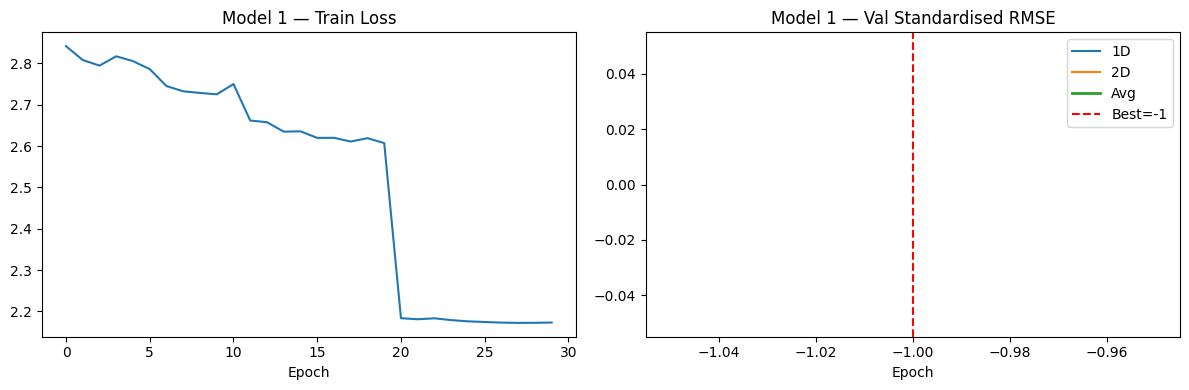


  Training Model 2
Model 2: train=61 events, val=8 events, test=30 events
  N_1D=198, N_2D=4299
  F_1D_in=22, F_2D_in=28
Model parameters: 128,514
Epoch   1/30  loss=0.82222  p_tf=1.00  176s
Epoch   2/30  loss=0.75638  p_tf=0.95  146s
Epoch   3/30  loss=0.73152  p_tf=0.90  155s  val=13.8107 (1D=19.0013 2D=8.6200)  ★ saved
Epoch   4/30  loss=0.71493  p_tf=0.85  146s
Epoch   5/30  loss=0.70096  p_tf=0.80  146s
Epoch   6/30  loss=0.69355  p_tf=0.75  153s  val=17.7553 (1D=26.7885 2D=8.7221)
Epoch   7/30  loss=0.68662  p_tf=0.70  146s
Epoch   8/30  loss=0.67932  p_tf=0.65  146s
Epoch   9/30  loss=0.67809  p_tf=0.60  154s  val=12.5702 (1D=22.2908 2D=2.8496)  ★ saved
Epoch  10/30  loss=0.66976  p_tf=0.55  149s
Epoch  11/30  loss=0.50038  p_tf=0.50  154s
Epoch  12/30  loss=0.49814  p_tf=0.45  160s  val=15.6169 (1D=24.4437 2D=6.7901)
Epoch  13/30  loss=0.49897  p_tf=0.40  152s
Epoch  14/30  loss=0.49560  p_tf=0.35  152s
Epoch  15/30  loss=0.49453  p_tf=0.30  160s  val=8.9517 (1D=15.4212 2D=2.4

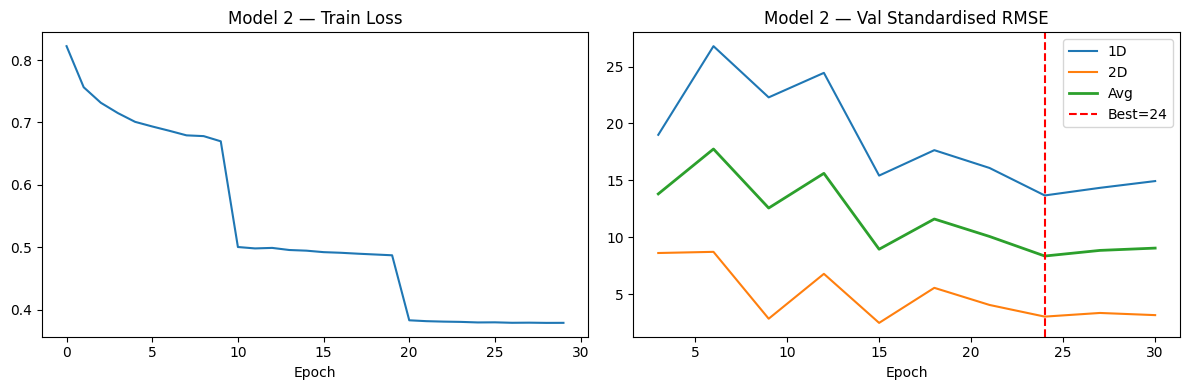


=== Training complete ===
  Model 1: best val RMSE = inf  | ckpt: /kaggle/working/best_model_1.pt
  Model 2: best val RMSE = 8.3548  | ckpt: /kaggle/working/best_model_2.pt


In [17]:
results = {}

for mid in [1, 2]:
    best_val, ckpt = train_one_model(mid)
    results[mid] = {'best_val': best_val, 'ckpt': str(ckpt)}

print('\n=== Training complete ===')
for mid, r in results.items():
    print(f'  Model {mid}: best val RMSE = {r["best_val"]:.4f}  | ckpt: {r["ckpt"]}')

## Cell 11 — Test inference

In [ ]:
@torch.no_grad()
def test_inference(model_id, ckpt_path):
    """
    Run fully autoregressive inference on all test events for one model.
    Returns dict: {event_id: (pred_wl_1d, pred_wl_2d)}
    """
    fc, static, split = load_model_config(model_id)
    edge_dict = make_edge_dict(static)
    model     = build_model(fc)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    WARMUP  = CFG['warmup_steps']
    invert  = static['invert_elevation'].cpu().numpy()
    minelev = static['min_elevation'].cpu().numpy()

    d1_mean = fc['depth_mean_1d']
    d1_std  = fc['std_depth_1d'] + 1e-8
    d2_mean = fc['depth_mean_2d']
    d2_std  = fc['std_depth_2d'] + 1e-8
    dd1_std = fc['std_delta_1d'] + 1e-8
    dd2_std = fc['std_delta_2d'] + 1e-8

    all_preds = {}

    for ev_path in tqdm(split['test'], desc=f'  M{model_id} inference'):
        ev_id = int(ev_path.stem.split('_')[1])
        ev    = load_event(ev_path)
        T     = ev['T']

        x_1d_full   = ev['x_1d_full']
        x_2d_full   = ev['x_2d_full']
        d1_warmup   = ev['depth_1d_warmup']
        d2_warmup   = ev['depth_2d_warmup']
        time_enc    = ev['time_enc']

        h_1d, h_2d = model.init_hidden(fc['n_1d'], fc['n_2d'])

        # Warmup + bias correction
        warm_preds_1d, warm_preds_2d = [], []
        cur_d1 = d1_warmup[0].clone()
        cur_d2 = d2_warmup[0].clone()

        for t in range(WARMUP):
            d1, d2, h_1d, h_2d = model.forward_step(
                x_1d_full[t], x_2d_full[t], time_enc[t],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])
            new_d1 = (cur_d1 + d1 * dd1_std).clamp(min=0.0)
            new_d2 = (cur_d2 + d2 * dd2_std).clamp(min=0.0)
            warm_preds_1d.append(new_d1)
            warm_preds_2d.append(new_d2)
            cur_d1, cur_d2 = new_d1, new_d2

        bias_1d = (d1_warmup - torch.stack(warm_preds_1d)).mean(0)
        bias_2d = (d2_warmup - torch.stack(warm_preds_2d)).mean(0)

        # Autoregressive rollout from warmup end
        cur_d1   = d1_warmup[-1].clone()
        cur_d2   = d2_warmup[-1].clone()
        cur_x1   = x_1d_full[WARMUP - 1].clone()
        cur_x2   = x_2d_full[WARMUP - 1].clone()
        preds_1d = []
        preds_2d = []

        for t in range(WARMUP, T):
            d1, d2, h_1d, h_2d = model.forward_step(
                cur_x1, cur_x2, time_enc[t],
                h_1d, h_2d, edge_dict,
                static['static_1d_node'], static['static_2d_node'])

            new_d1 = (cur_d1 + d1 * dd1_std + bias_1d).clamp(min=0.0)
            new_d2 = (cur_d2 + d2 * dd2_std + bias_2d).clamp(min=0.0)
            preds_1d.append(new_d1.cpu().numpy())
            preds_2d.append(new_d2.cpu().numpy())

            d1_n = (new_d1 - d1_mean) / d1_std
            d2_n = (new_d2 - d2_mean) / d2_std
            t_next = min(t + 1, T - 1)
            cur_x1 = update_dyn(cur_x1, d1_n, x_1d_full[t_next])
            cur_x2 = update_dyn(cur_x2, d2_n, x_2d_full[t_next])
            cur_d1, cur_d2 = new_d1, new_d2

        pred_d1 = np.stack(preds_1d) + invert[np.newaxis, :]   # -> WL
        pred_d2 = np.stack(preds_2d) + minelev[np.newaxis, :]

        all_preds[ev_id] = (pred_d1, pred_d2)

        del ev
        gc.collect()
        if DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    del model, static
    gc.collect()
    return all_preds, fc


print('test_inference() defined.')

test_inference() defined.


## Cell 12 — Build submission CSV

In [ ]:
import pandas as pd

def _load_node_ids_for_model(model_id, fc):
    out_dir = PREP_ROOT / f'model_{model_id}'
    node_json = out_dir / 'node_ids.json'
    if node_json.exists():
        with open(node_json) as f:
            d = json.load(f)
        node_ids_1d = d.get('node_ids_1d', list(range(fc['n_1d'])))
        node_ids_2d = d.get('node_ids_2d', list(range(fc['n_2d'])))
        if len(node_ids_1d) == fc['n_1d'] and len(node_ids_2d) == fc['n_2d']:
            return node_ids_1d, node_ids_2d

    # Safe fallback when node_ids.json is unavailable
    return list(range(fc['n_1d'])), list(range(fc['n_2d']))

def build_submission(model_ids=(1, 2)):
    all_rows = []
    row_id   = 0

    # Keep only models with available checkpoints
    run_models = []
    for model_id in model_ids:
        ckpt_path = OUT_DIR / f'best_model_{model_id}.pt'
        if ckpt_path.exists():
            run_models.append(model_id)
        else:
            print(f'Skipping Model {model_id} (missing checkpoint: {ckpt_path})')

    if len(run_models) == 0:
        raise FileNotFoundError('No model checkpoints found. Train at least one model first.')

    for model_id in run_models:
        ckpt_path = OUT_DIR / f'best_model_{model_id}.pt'
        print(f'Running inference for Model {model_id}...')
        preds, fc = test_inference(model_id, ckpt_path)
        node_ids_1d, node_ids_2d = _load_node_ids_for_model(model_id, fc)

        for ev_id, (pred_wl_1d, pred_wl_2d) in preds.items():
            T_pred = pred_wl_1d.shape[0]
            for t in range(T_pred):
                for ni, nid in enumerate(node_ids_1d):
                    all_rows.append({
                        'row_id':      row_id,
                        'model_id':    model_id,
                        'event_id':    ev_id,
                        'node_type':   1,
                        'node_id':     nid,
                        'water_level': float(pred_wl_1d[t, ni]),
                    })
                    row_id += 1
                for ni, nid in enumerate(node_ids_2d):
                    all_rows.append({
                        'row_id':      row_id,
                        'model_id':    model_id,
                        'event_id':    ev_id,
                        'node_type':   2,
                        'node_id':     nid,
                        'water_level': float(pred_wl_2d[t, ni]),
                    })
                    row_id += 1

        del preds
        gc.collect()

    sub = pd.DataFrame(all_rows)
    sub_path = OUT_DIR / 'submission.csv'
    sub.to_csv(sub_path, index=False)
    print(f'\nSubmission saved: {sub_path}')
    print(f'Rows: {len(sub):,}')
    print(f'WL range: [{sub["water_level"].min():.3f}, {sub["water_level"].max():.3f}]')
    print(sub.head())
    return sub


sub = build_submission(model_ids=(1, 2))

Running inference for Model 2...
Model 2: train=61 events, val=8 events, test=30 events
  N_1D=198, N_2D=4299
  F_1D_in=22, F_2D_in=28
Model parameters: 128,514


  M2 inference:   0%|          | 0/30 [00:00<?, ?it/s]


Submission saved: /kaggle/working/submission.csv
Rows: 32,297,454
WL range: [23.000, 838.776]
   row_id  model_id  event_id  node_type  node_id  water_level
0       0         2         4          1        0    36.060001
1       1         2         4          1        1    38.169998
2       2         2         4          1        2    31.559999
3       3         2         4          1        3    37.400002
4       4         2         4          1        4    38.639999


## Cell 13 — Final summary

In [21]:
if DEVICE.type == 'cuda':
    alloc    = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved()  / 1e9
    total    = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU memory — allocated: {alloc:.2f} GB / reserved: {reserved:.2f} GB / total: {total:.1f} GB')

print('\n' + '='*60)
print('  DONE')
print('='*60)
for mid, r in results.items():
    print(f'  Model {mid}: best val RMSE = {r["best_val"]:.4f}')
print(f'  Submission rows: {len(sub):,}')
print(f'  File: /kaggle/working/submission.csv')
print('='*60)

GPU memory — allocated: 0.04 GB / reserved: 0.17 GB / total: 17.1 GB

  DONE
  Model 1: best val RMSE = inf
  Model 2: best val RMSE = 8.3548
  Submission rows: 32,297,454
  File: /kaggle/working/submission.csv
